### Import das Classes

In [1]:
import matplotlib.pyplot as plt
from src.ProblemaP1 import ProblemaP1
from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP2 import ProblemaP2

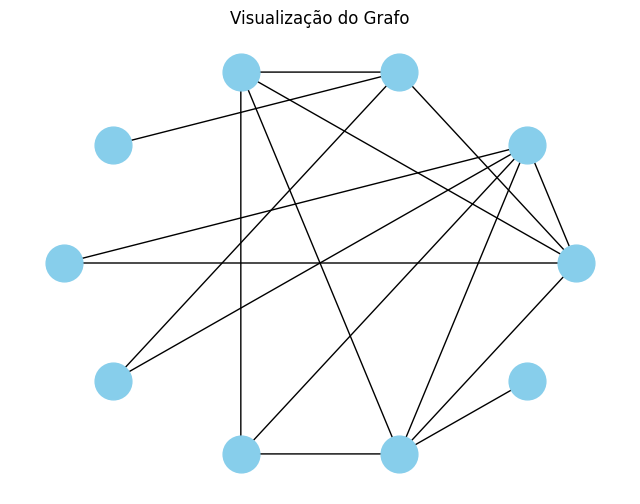

In [ ]:
generator = ProblemaP1Generator(seed=42)
mu=1
patm=10
prob = generator.generate(num_nodes=10, edge_prob=0.15, mu=mu, patm=patm)

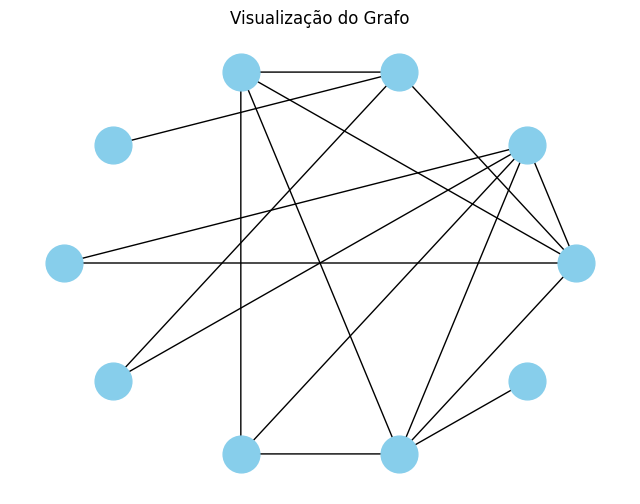

In [3]:
# Resolver problema determinístico
prob.setup()
prob.solve()
prob.plot(show_edge_labels=False, show_node_labels=False, layout='circular')

In [4]:
isinstance(prob, ProblemaP1)

True

In [18]:
# Criar problema probabilístico
probabilistic_problem = ProblemaP2(
    p1_instance=prob, 
    r_prob=0.3,      # 30% de chance de obstrução
    alpha=2,         # resistência dobra
    P_max=500,         # pressão máxima = 1
    n_samples=1000,  # 1000 simulações
    seed=42
)

In [19]:
probabilistic_problem.setup()

In [20]:
# ==========================================
# TESTE 1: Análise completa com run()
# ==========================================
print("=" * 50)
print("Executando análise completa com 1000 simulações...")
probabilistic_problem.run()

print(f"\n📊 RESULTADOS:")
print(f"Probabilidade de falha: {probabilistic_problem.probability_of_failure():.4f} ({probabilistic_problem.probability_of_failure():.2%})")
print(f"Média da pressão máxima: {probabilistic_problem.summary()['mean_max_pressure']:.4f}")
print(f"Desvio padrão: {probabilistic_problem.summary()['std_max_pressure']:.4f}")

Executando análise completa com 1000 simulações...

📊 RESULTADOS:
Probabilidade de falha: 0.3040 (30.40%)
Média da pressão máxima: 527.7256
Desvio padrão: 149.6652


In [21]:
# ==========================================
# TESTE 2: Estimativa rápida
# ==========================================
print("\n" + "=" * 50)
print("Estimativa rápida com 100 simulações...")
pf, ic_low, ic_high = probabilistic_problem.estimate_pf(n_iter=100)
print(f"P_f = {pf:.4f} ({pf:.2%})")
print(f"IC 95%: [{ic_low:.4f}, {ic_high:.4f}]")


Estimativa rápida com 100 simulações...
P_f = 0.3500 (35.00%)
IC 95%: [0.2565, 0.4435]



Visualizando a rede...


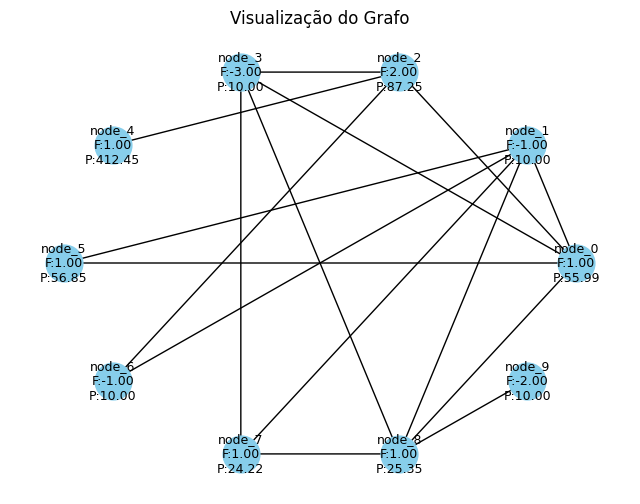


✅ Todos os testes concluídos!


In [22]:
# ==========================================
# TESTE 3: Visualização
# ==========================================
print("\n" + "=" * 50)
print("Visualizando a rede...")
probabilistic_problem.plot(show_edge_labels=False, show_node_labels=True, layout='circular')

print("\n✅ Todos os testes concluídos!")

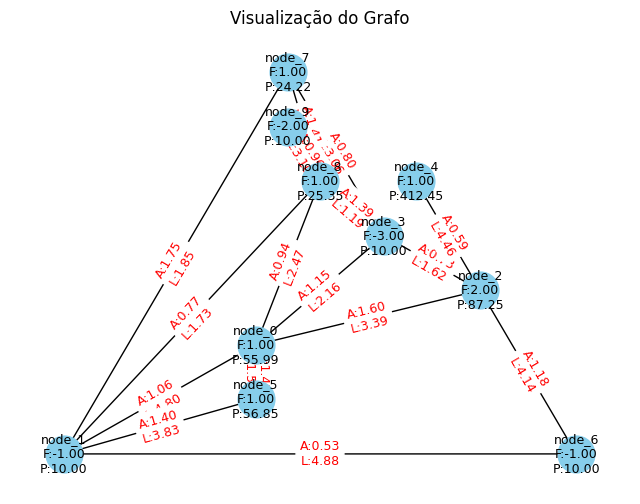

In [23]:
prob.setup().solve()
prob.plot()

In [24]:
# Ver resultados
print(probabilistic_problem.summary())

{'n_samples': 1000, 'P_fail': 0.304, 'IC_95%': (np.float64(0.2754905064387712), np.float64(0.3325094935612288)), 'mean_max_pressure': 527.7255632456078, 'std_max_pressure': 149.66521120066565, 'max_pressure_observed': 802.9288880746456, 'node_failure_prob': [0.0, 0.0, 0.0, 0.0, 0.304, 0.0, 0.0, 0.0, 0.0, 0.0]}


In [25]:
# Estimar com mais precisão
pf, ci_lower, ci_upper = probabilistic_problem.estimate_pf(n_iter=500)
print(f"\nP_f = {pf:.4f} (IC 95%: [{ci_lower:.4f}, {ci_upper:.4f}])")


P_f = 0.2980 (IC 95%: [0.2579, 0.3381])


In [26]:
probabilistic_problem.estimate_pf(n_iter=100)

(0.23, np.float64(0.1475183440306313), np.float64(0.3124816559693687))